# Parte 1: Análise Exploratória 

---

## Objetivos da Análise

Esta etapa inicial visa compreender a estrutura, volume e comportamento estatístico do corpus de chamados da Central 1746, tentando identificar padrões, desvios sistemáticos e potenciais sinais preditivos nos metadados que possam guiar ou enviesar a avaliação dos classificadores automáticos (Modelos A e B).

A análise está estruturada em três etapas:
1. **Visão Macro da Base e Variável Target:** Diagnóstico estrutural e avaliação do desbalanceamento de classes.
2. **Análise de Distribuição e Perfis Operacionais:** Investigação de volumes, padrões por canal de entrada, perfis textuais e concentração geográfica.
3. **Teste de Independência Estatística (Metadados vs. Target):** Validação estatística com `p-value` da relevância dos atributos tabulares na predição da categoria real.

---

## Etapa 1: Estrutura e Target (`categoria_real`)

Neste primeiro bloco, realizamos uma auditoria técnica na dimensionalidade da base, integridade dos tipos de dados e consistência das 5.000 observações sintéticas. O foco central é mapear o comportamento da variável dependente (`categoria_real`).

### Implicações Metodológicas Antecipadas:
* **Métricas de Avaliação:** Caso seja confirmado um desbalanceamento de classes, a métrica de Acurácia Global torna-se um indicador frágil e enviesado. Estabeleceremos o F1-Score Macro (média não ponderada do F1 de cada categoria) e o F1-Score Ponderado como critérios norteadores para a auditoria dos modelos, garantindo que a performance em classes minoritárias não seja mascarada pelo volume das classes majoritárias.


In [22]:
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import chi2_contingency

DATA_PATH = Path("../dados/chamados_com_predicoes.csv")

# Padrão visual para os gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

### 1.1. Sumário da Tabela

Nesta seção é apresentada uma visão geral da base de dados, verificando sua estrutura, tipos de atributos, presença de valores ausentes, duplicatas e informações básicas sobre o período e a cardinalidade das variáveis.

In [15]:
df = pd.read_csv(DATA_PATH, parse_dates=["data_abertura"])

print("=== Shape ===")
print(df.shape)

print("\n=== Info ===")
df.info()

print("\n=== Primeiras linhas ===")
print(df.head())

print("\n=== Valores ausentes ===")
print(df.isnull().sum())

print("\n=== Linhas duplicadas ===")
print(df.duplicated().sum())

print("\n=== Valores únicos por coluna ===")
print(df.nunique())

print("\n=== Intervalo das datas ===")
print("Mínima:", df["data_abertura"].min())
print("Máxima:", df["data_abertura"].max())

=== Shape ===
(5000, 10)

=== Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   id_chamado      5000 non-null   int64         
 1   data_abertura   5000 non-null   datetime64[ns]
 2   bairro          5000 non-null   object        
 3   canal           5000 non-null   object        
 4   texto           5000 non-null   object        
 5   categoria_real  5000 non-null   object        
 6   pred_modelo_a   5000 non-null   object        
 7   conf_modelo_a   5000 non-null   float64       
 8   pred_modelo_b   5000 non-null   object        
 9   conf_modelo_b   5000 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 390.8+ KB

=== Primeiras linhas ===
   id_chamado data_abertura              bairro          canal  \
0  2026003525    2026-01-16            Botafogo       a

### 1.2. Visualização do Target

Antes de avaliar o desempenho dos classificadores, é importante analisar a distribuição da variável alvo (`categoria_real`). A frequência de cada categoria permite identificar se o conjunto de dados é balanceado ou se existem classes significativamente mais representadas que outras, informação que influencia diretamente a escolha das métricas de avaliação.

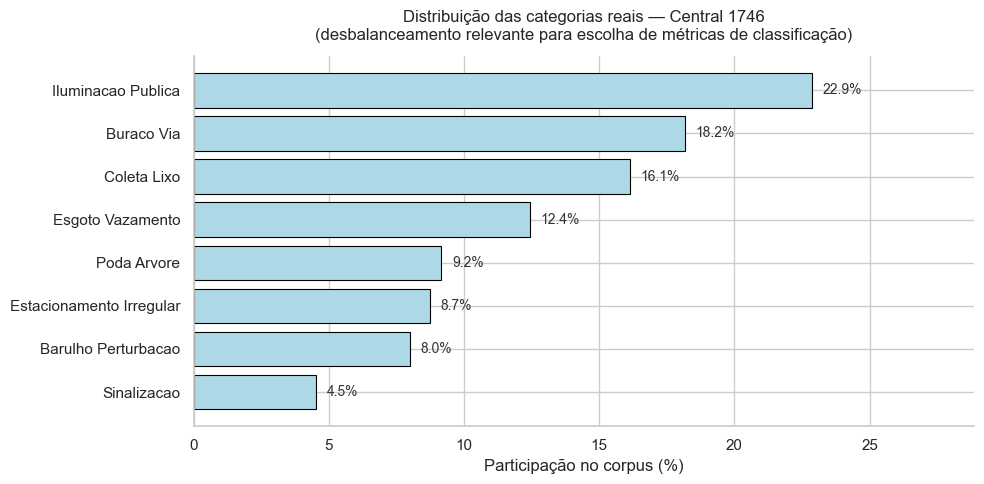

In [12]:
# Ordenação decrescente facilita leitura executiva e comparação entre classes majoritárias e minoritárias
dist_pct = (
    df["categoria_real"]
    .value_counts(normalize=True)
    .mul(100)
    .sort_values(ascending=True)
)

plot_df = dist_pct.reset_index()
plot_df.columns = ["categoria_real", "percentual"]
plot_df["rotulo"] = plot_df["percentual"].map(lambda x: f"{x:.1f}%")

fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(
    plot_df["categoria_real"].str.replace("_", " ").str.title(),
    plot_df["percentual"],
    color="lightblue",
    edgecolor="black",
    linewidth=0.8,
)

# Percentuais nos rótulos — gestores precisam do valor exato, não apenas da comparação visual
for bar, rotulo in zip(bars, plot_df["rotulo"]):
    ax.text(
        bar.get_width() + 0.4,
        bar.get_y() + bar.get_height() / 2,
        rotulo,
        va="center",
        ha="left",
        fontsize=10,
        color="#333333",
    )

ax.set_xlabel("Participação no corpus (%)")
ax.set_ylabel("")
ax.set_title(
    "Distribuição das categorias reais — Central 1746\n"
    "(desbalanceamento relevante para escolha de métricas de classificação)",
    pad=12,
)
ax.set_xlim(0, plot_df["percentual"].max() + 6)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

### Análise dos resultados

Observa-se que as categorias não estão distribuídas de maneira uniforme, havendo classes mais frequentes que outras. Esse desbalanceamento pode fazer com que métricas como a acurácia apresentem resultados excessivamente otimistas, uma vez que erros nas classes minoritárias têm menor impacto sobre o valor final da métrica.

Dessa forma, nas próximas análises será utilizada principalmente a métrica F1 Macro, que calcula o F1 individualmente para cada classe e, em seguida, realiza a média entre elas, atribuindo o mesmo peso a todas as categorias independentemente de sua frequência no conjunto de dados.

## Etapa 2: Perfis Operacionais, Padrões Temporais e Características de Texto

Com a estrutura geral mapeada, esta etapa investiga o comportamento das variáveis independentes (bairro, canal e comportamento do texto) para entender como o cidadão interage com o sistema 1746. 

Neste bloco, avaliamos:
* **Concentração Geográfica e Demanda:** Mapeamento dos bairros com maior volume absoluto de chamados para entender focos de pressão urbana.
* **Perfis dos Canais de Entrada:** Investigação sobre se o canal escolhido (App, Telefone, Web) dita o comportamento do usuário.
* **Complexidade Textual:** Análise do comprimento das manifestações (contagem de palavras). Avaliaremos se determinados canais induzem o cidadão a escrever textos mais curtos, truncados ou mais detalhados, o que impacta diretamente a capacidade de extração de padrões por modelos NLP

## 2.1. Complexidade do Texto e Canal de Entrada

O canal pode alterar a riqueza do texto enviado ao classificador: chamadas telefônicas podem ter transcrições mais longas e informais, enquanto o app pode incentivar descrições curtas e estruturadas. Diferenças no tamanho do texto entre canais são um confundidor potencial, onde na Fase 2, verificaremos se algum canal concentra mais erros de classificação.

C:\Users\João Gabriel\AppData\Local\Temp\ipykernel_17828\1719241896.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


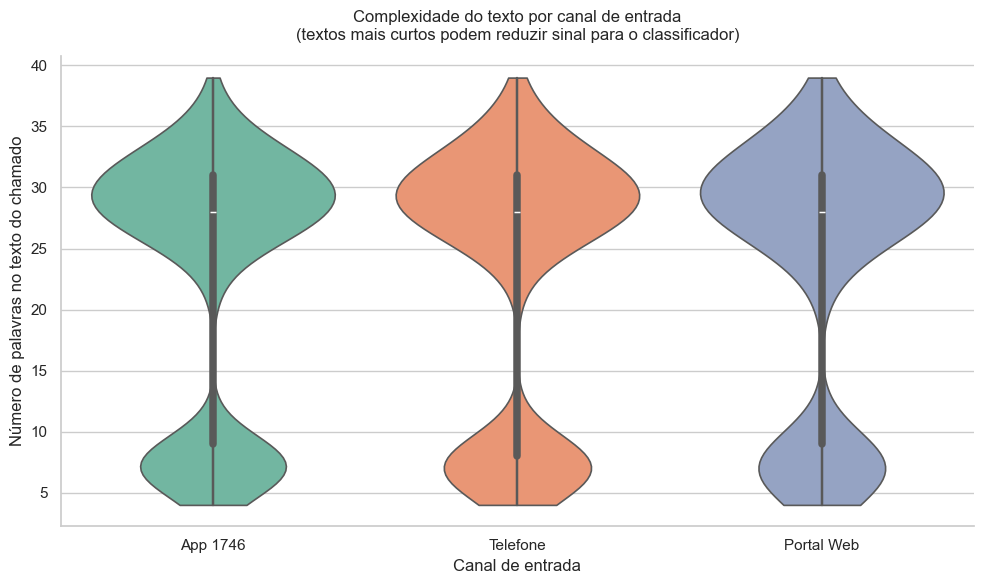

=== Mediana de palavras por canal ===
canal_label
App 1746      28.0
Telefone      28.0
Portal Web    28.0
Name: tamanho_texto, dtype: float64


In [19]:
# Contagem de palavras (e não caracteres) reflete melhor a complexidade semântica percebida pelo classificador
df["tamanho_texto"] = df["texto"].str.split().str.len()

CANAL_LABELS = {
    "app_1746": "App 1746",
    "telefone_1746": "Telefone",
    "portal_web": "Portal Web",
}
df["canal_label"] = df["canal"].map(CANAL_LABELS)

# Ordem fixa para comparação direta entre app e telefone (hipótese central da análise)
ordem_canais = ["App 1746", "Telefone", "Portal Web"]

fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(
    data=df,
    x="canal_label",
    y="tamanho_texto",
    order=ordem_canais,
    inner="box",
    palette="Set2",
    linewidth=1.2,
    ax=ax,
    cut=0,
)
ax.set_xlabel("Canal de entrada")
ax.set_ylabel("Número de palavras no texto do chamado")
ax.set_title(
    "Complexidade do texto por canal de entrada\n"
    "(textos mais curtos podem reduzir sinal para o classificador)",
    pad=12,
)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

# Estatísticas descritivas para quantificar a diferença app vs. telefone
print("=== Mediana de palavras por canal ===")
print(df.groupby("canal_label")["tamanho_texto"].median().reindex(ordem_canais))

## 2.2. Padrões Temporais e Espaciais

Picos de volume ou concentração geográfica de chamados podem estressar a operação e, indiretamente, a qualidade da classificação automática (ex.: surtos sazonais de uma categoria ou bairros com mix distinto de serviços). Mapeamos a evolução temporal e os bairros de maior demanda para contextualizar a amostra antes da auditoria dos modelos.

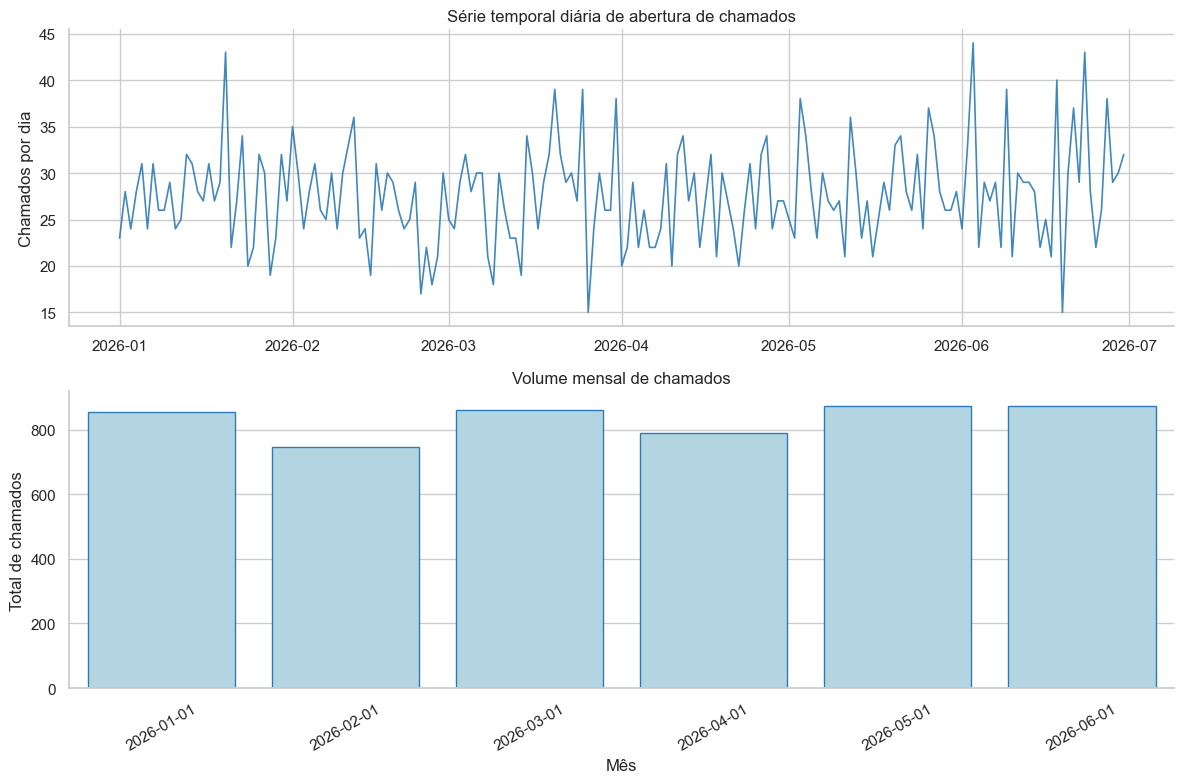


=== Lista de bairros por mais chamados ===
                    n_chamados  percentual
bairro                                    
Campo Grande               533       10.66
Jacarepaguá                467        9.34
Bangu                      435        8.70
Barra da Tijuca            403        8.06
Tijuca                     387        7.74
Santa Cruz                 358        7.16
Copacabana                 350        7.00
Madureira                  340        6.80
Centro                     305        6.10
Realengo                   277        5.54
Irajá                      271        5.42
Botafogo                   270        5.40
Méier                      269        5.38
Penha                      194        3.88
Ilha do Governador         141        2.82


In [ ]:
# Agregação diária captura sazonalidade e eventos pontuais; mensal resume tendência para gestores
chamados_dia = (
    df.groupby(df["data_abertura"].dt.date)
    .size()
    .reset_index(name="n_chamados")
)
chamados_dia.columns = ["data", "n_chamados"]
chamados_dia["data"] = pd.to_datetime(chamados_dia["data"])

chamados_mes = (
    df.groupby(df["data_abertura"].dt.to_period("M"))
    .size()
    .reset_index(name="n_chamados")
)
chamados_mes["mes"] = chamados_mes["data_abertura"].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=False)

axes[0].plot(
    chamados_dia["data"],
    chamados_dia["n_chamados"],
    color="#2c7bb6",
    linewidth=1.2,
    alpha=0.9,
)
axes[0].set_ylabel("Chamados por dia")
axes[0].set_title("Série temporal diária de abertura de chamados")
axes[0].spines[["top", "right"]].set_visible(False)

sns.barplot(
    data=chamados_mes,
    x="mes",
    y="n_chamados",
    color="#abd9e9",
    edgecolor="#2c7bb6",
    ax=axes[1],
)
axes[1].set_xlabel("Mês")
axes[1].set_ylabel("Total de chamados")
axes[1].set_title("Volume mensal de chamados")
axes[1].tick_params(axis="x", rotation=30)
axes[1].spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

print("\n=== Lista de bairros por mais chamados ===")
top_bairros = df["bairro"].value_counts()
top_bairros_pct = (top_bairros / len(df) * 100).round(2)
top_resumo = pd.DataFrame({"n_chamados": top_bairros, "percentual": top_bairros_pct})
print(top_resumo)

## 2.3. Canal vs. categorias (teste de independência)

Agora, analisaremos se o canal e o nosso target de categoria são ou não independentes, além de fazermos uma análise sobre qual canal temos mais chamadas, e se temos um número relevante para cada um deles.


=== Lista de canal por mais chamados ===
               n_chamados  percentual
canal                                
app_1746             2408       48.16
telefone_1746        1724       34.48
portal_web            868       17.36


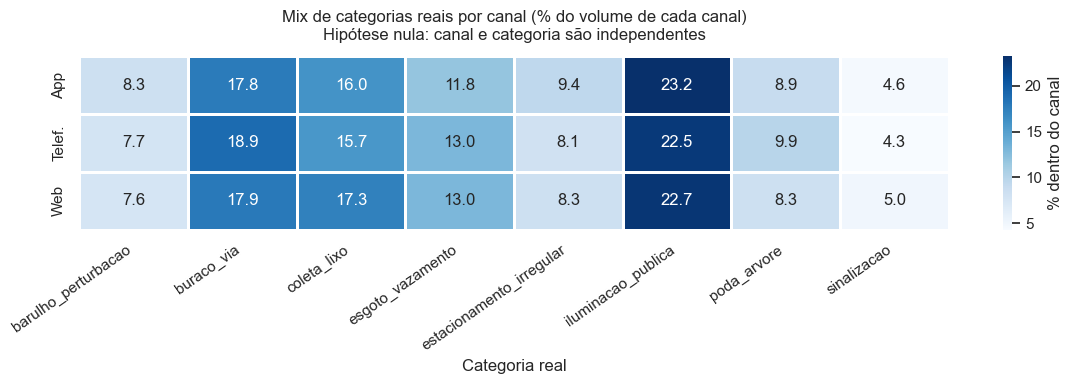

=== Teste χ² de independência: canal x categoria_real ===


,estatistica,graus_liberdade,p_valor,alpha,rejeita_H0
0,8.7884,14,0.8444,0.05,False


In [26]:
print("\n=== Lista de canal por mais chamados ===")
top_canal = df["canal"].value_counts()
top_canal_pct = (top_canal / len(df) * 100).round(2)
top_resumo = pd.DataFrame({"n_chamados": top_canal, "percentual": top_canal_pct})
print(top_resumo)

CANAL_LABELS = {
        "app_1746": "App",
        "telefone_1746": "Telef.",
        "portal_web": "Web",
    }
df["canal_label"] = df["canal"].map(CANAL_LABELS)

# Tabela de contingência bruta para o teste χ²
tab_canal_categoria = pd.crosstab(df["canal_label"], df["categoria_real"])
chi2, p_valor, graus_liberdade, _ = chi2_contingency(tab_canal_categoria)

# Heatmap: % dentro de cada canal (coluna), compara mix relativo entre canais
tab_pct_coluna = (
    tab_canal_categoria.div(tab_canal_categoria.sum(axis=1), axis=0)
    .mul(100)
    .round(1)
)
tab_pct_coluna.index.name = "canal"

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(
    tab_pct_coluna,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=1,
    cbar_kws={"label": "% dentro do canal"},
    ax=ax,
)
ax.set_title(
    "Mix de categorias reais por canal (% do volume de cada canal)\n"
    "Hipótese nula: canal e categoria são independentes",
    pad=12,
)
ax.set_xlabel("Categoria real")
ax.set_ylabel("")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# Tabela: resultado do teste + interpretação para a auditoria dos classificadores
tab_teste_canal = pd.DataFrame(
    {
        "estatistica": [chi2],
        "graus_liberdade": [graus_liberdade],
        "p_valor": [p_valor],
        "alpha": [0.05],
        "rejeita_H0": [p_valor < 0.05],
    }
).round(4)

print("=== Teste χ² de independência: canal x categoria_real ===")
display(tab_teste_canal)

### Resultado

Tanto pela análise do gráfico quanto pelo teste de independência qui-quadrado, podemos ver que não há correlação aparente entre as duas colunas.

## 2.4. Análise bairro x categoria

Agora, analisaremos se há correlação entre o bairro e a categoria do chamado

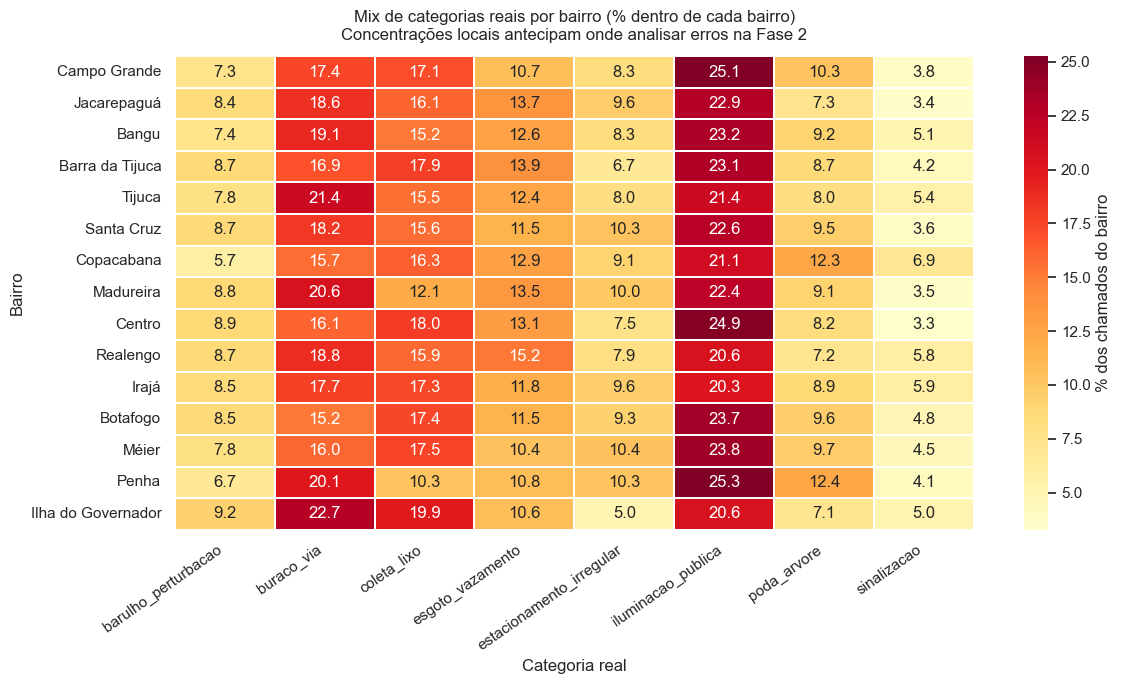

=== Teste χ² de independência: bairro x categoria_real ===


,estatistica,graus_liberdade,p_valor,alpha,rejeita_H0
0,71.5196,98,0.9796,0.05,False


In [28]:
# Tabela de contingência
tab_bairro_categoria = pd.crosstab(df["bairro"], df["categoria_real"])

# % por bairro (linha): perfil de demanda local
tab_bairro_pct = tab_bairro_categoria.div(
    tab_bairro_categoria.sum(axis=1), axis=0
).mul(100)

# Ordena bairros pelo volume total
ordem_bairros = tab_bairro_categoria.sum(axis=1).sort_values(ascending=False).index

fig, ax = plt.subplots(figsize=(12, 7))

sns.heatmap(
    tab_bairro_pct.loc[ordem_bairros],
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.3,
    cbar_kws={"label": "% dos chamados do bairro"},
    ax=ax,
)

ax.set_title(
    "Mix de categorias reais por bairro (% dentro de cada bairro)\n"
    "Concentrações locais antecipam onde analisar erros na Fase 2",
    pad=12,
)
ax.set_xlabel("Categoria real")
ax.set_ylabel("Bairro")

plt.xticks(rotation=35, ha="right")
plt.tight_layout()
plt.show()

# Teste χ² de independência
chi2, p_valor, graus_liberdade, _ = chi2_contingency(tab_bairro_categoria)

tab_teste = pd.DataFrame(
    {
        "estatistica": [chi2],
        "graus_liberdade": [graus_liberdade],
        "p_valor": [p_valor],
        "alpha": [0.05],
        "rejeita_H0": [p_valor < 0.05],
    }
).round(4)

print("=== Teste χ² de independência: bairro x categoria_real ===")
display(tab_teste)

### Resultado

Tanto pela análise do gráfico quanto pelo teste de independência qui-quadrado, podemos ver que não há correlação aparente entre as duas colunas.

## 2.5. Preview de viés nas predições (sem calcular acurácia)

Comparar apenas as frequências marginais de `categoria_real` vs. `pred_modelo_a` e `pred_modelo_b` antecipa desvios sistemáticos (ex.: superestimar uma classe), pistas para a matriz de confusão na Fase 2, sem ainda medir acerto por chamado.

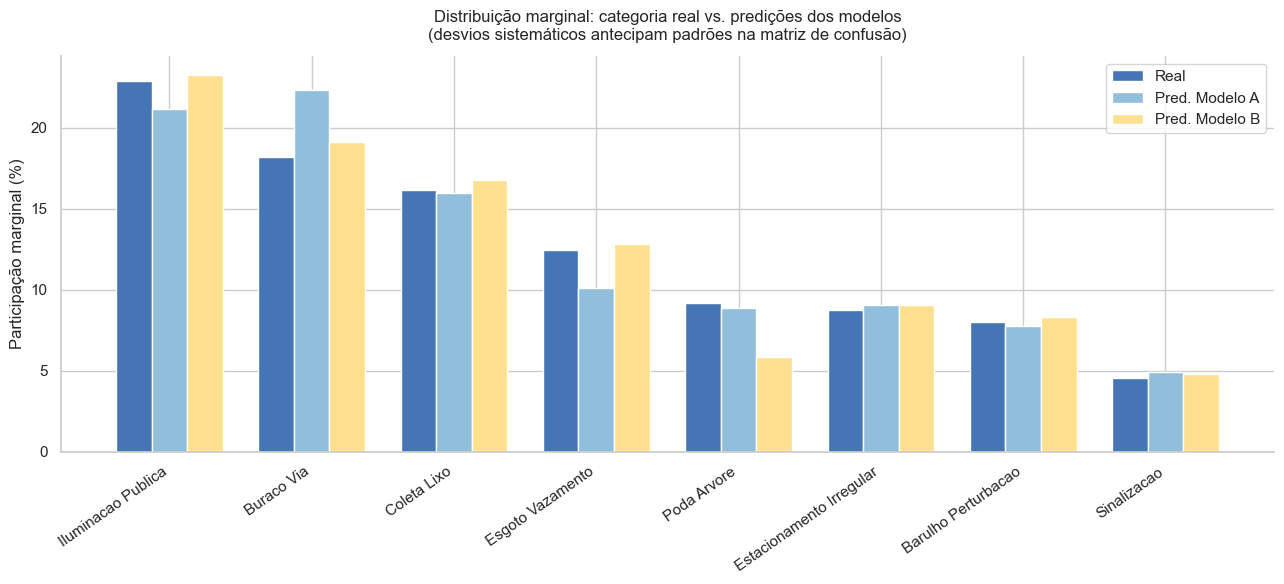

=== Tabela marginal (% ) e desvio em relação ao rótulo real ===


,real_pct,pred_a_pct,pred_b_pct,delta_a_vs_real,delta_b_vs_real
iluminacao_publica,22.86,21.14,23.24,-1.72,0.38
buraco_via,18.16,22.34,19.12,4.18,0.96
coleta_lixo,16.12,15.96,16.78,-0.16,0.66
esgoto_vazamento,12.42,10.08,12.84,-2.34,0.42
poda_arvore,9.16,8.84,5.86,-0.32,-3.30
estacionamento_irregular,8.74,9.02,9.06,0.28,0.32
barulho_perturbacao,8.00,7.74,8.30,-0.26,0.30
sinalizacao,4.54,4.88,4.80,0.34,0.26


In [29]:
# Frequências marginais alinhadas à ordem do desbalanceamento global
ordem_categorias = (
    df["categoria_real"].value_counts().index.tolist()
)

tab_marginais = pd.DataFrame(
    {
        "real_pct": df["categoria_real"]
        .value_counts(normalize=True)
        .reindex(ordem_categorias)
        .mul(100),
        "pred_a_pct": df["pred_modelo_a"]
        .value_counts(normalize=True)
        .reindex(ordem_categorias)
        .mul(100),
        "pred_b_pct": df["pred_modelo_b"]
        .value_counts(normalize=True)
        .reindex(ordem_categorias)
        .mul(100),
    }
).round(2)
tab_marginais["delta_a_vs_real"] = tab_marginais["pred_a_pct"] - tab_marginais["real_pct"]
tab_marginais["delta_b_vs_real"] = tab_marginais["pred_b_pct"] - tab_marginais["real_pct"]

x = np.arange(len(ordem_categorias))
largura = 0.25
rotulos_x = [c.replace("_", " ").title() for c in ordem_categorias]

fig, ax = plt.subplots(figsize=(13, 6))
ax.bar(x - largura, tab_marginais["real_pct"], largura, label="Real", color="#4575b4")
ax.bar(x, tab_marginais["pred_a_pct"], largura, label="Pred. Modelo A", color="#91bfdb")
ax.bar(x + largura, tab_marginais["pred_b_pct"], largura, label="Pred. Modelo B", color="#fee090")

ax.set_xticks(x)
ax.set_xticklabels(rotulos_x, rotation=35, ha="right")
ax.set_ylabel("Participação marginal (%)")
ax.set_title(
    "Distribuição marginal: categoria real vs. predições dos modelos\n"
    "(desvios sistemáticos antecipam padrões na matriz de confusão)",
    pad=12,
)
ax.legend()
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("=== Tabela marginal (% ) e desvio em relação ao rótulo real ===")
display(tab_marginais)

## Etapa 3: Teste de Independência Estatística (Qui-Quadrado de Pearson)

Para consolidar as hipóteses levantadas nas etapas anteriores e garantir o rigor analítico, aplicamos o **Teste Qui-Quadrado de Pearson**. 

O objetivo é responder matematicamente à seguinte questão: *Os metadados estruturados (bairro, canal, dia da semana ou comprimento do texto) carregam algum sinal estatístico preditivo sobre a categoria real do chamado?*

### Definição do Teste:
* **Hipótese Nula ($H_0$):** A variável de metadado (ex: `canal`) e a variável alvo (`categoria_real`) são estatisticamente independentes.
* **Hipótese Alternativa ($H_1$):** Existe associação estatisticamente significante entre as variáveis.
* **Critério de Decisão:** Nível de significância padrão de 5% ($\alpha = 0.05$). Um $p\text{-valor} \ge 0.05$ indicará que a variável avaliada é essencialmente ruído estatístico para a tarefa de classificação, isolando o peso do sucesso preditivo exclusivamente à semântica e sintaxe contidas na variável descritiva `texto`.

In [30]:
# Nova feature booleana -> texto longo=True se tiver mais de 15 palavras
df['texto_longo'] = df['texto'].apply(lambda x: len(str(x).split()) > 15).astype(int)
df['dia_semana'] = df['data_abertura'].dt.dayofweek

features_para_testar = ['bairro', 'canal', 'dia_semana', 'texto_longo']
target = 'categoria_real'

resultados = []

# Rodando o Qui-Quadrado
for feature in features_para_testar:
    tabela_contingencia = pd.crosstab(df[feature], df[target])

    chi2, p_value, dof, expected = chi2_contingency(tabela_contingencia)
    
    resultados.append({
        'Feature': feature,
        'p-value': p_value,
        'Relevante para Predição?': 'Sim' if p_value < 0.05 else 'Não'
    })

df_summary = pd.DataFrame(resultados)
print("=== Relevância das Features para prever a Categoria (Qui-Quadrado) ===")
print(df_summary.to_markdown(index=False))

=== Relevância das Features para prever a Categoria (Qui-Quadrado) ===
| Feature     |   p-value | Relevante para Predição?   |
|:------------|----------:|:---------------------------|
| bairro      |  0.979633 | Não                        |
| canal       |  0.844363 | Não                        |
| dia_semana  |  0.462995 | Não                        |
| texto_longo |  0.773845 | Não                        |


### Conclusão da Análise Exploratória e Impacto na Modelagem

Os resultados do Teste Qui-Quadrado revelam um cenário para a nossa avaliação: **nenhum dos metadados estruturados apresentou significância estatística** (todos os p-valores foram bem maiores que 0.05). Adicionalmente, verificamos previamente também que a complexidade da entrada (mediana de 28 palavras) é idêntica independentemente do canal de atendimento.

**Implicações operacionais e técnicas:**
1. **Independência de Contexto Externo:** A proporção de categorias de chamados não flutua estatisticamente com base em geografia (bairros), tempo (dia da semana) ou origem (canal). 
2. **Dependência Semântica:** Como as variáveis tabulares são essencialmente ruído estatístico para a predição do target, a capacidade de classificação dos Modelos A e B deve estar focada exclusivamente na extração semântica da variável `texto`. 
3. **Diretriz para Auditoria:** Na próxima fase, ao auditarmos os modelos, saberemos que qualquer viés de performance encontrado será derivado de como a arquitetura do modelo processa a linguagem natural.

# Conclusões Finais da Fase 1:

* **1. Desbalanceamento do Target:**
    * A classe majoritária (`iluminacao_publica`) representa quase 23% dos chamados, enquanto classes minoritárias (como `sinalizacao`) não chegam a 5%.
    * *Impacto no Classificador:* Invalida o uso da Acurácia Global como métrica principal de avaliação na Fase 2. Modelos ingenuos que apenas predigam a classe majoritária apresentarão métricas ilusoriamente altas. Exigirá o uso do F1-Score Macro/Weighted e uma avaliação rigorosa isolada por categoria.
* **2. Independência Estatística dos Metadados (Ruído):**
    * Testes Qui-Quadrado de Pearson comprovaram que a distribuição das categorias de chamados independe da geografia (`bairro`, p-valor ≈ 0.98), do tempo (`dia_semana`, p-valor ≈ 0.46) ou da origem (`canal`, p-valor ≈ 0.84).
    * *Impacto no Classificador:* Define a arquitetura do modelo. O classificador em produção não deve utilizar atributos tabulares como features estruturadas, pois eles agem como ruído e não carregam sinal preditivo real. O peso do sucesso da decisão classificatória recai puramente na extração semântica da variável textual.
* **3. Homogeneidade na Complexidade da Entrada (Texto):**
    * O comprimento das manifestações escritas pelo cidadão (mediana estável em 28 palavras) e a presença de indicadores booleanos de textos longos (`texto_longo`, p-valor ≈ 0.77) permanecem constantes em todos os canais de entrada (App, Telefone, Web).
    * *Impacto no Classificador:* Simplifica o pipeline de engenharia de dados e pré-processamento. Não há necessidade de construir rotinas de Processamento de Linguagem Natural (NLP) separadas ou regras de truncamento específicas dependendo da origem do chamado, já que o modelo enfrentará uma complexidade textual padronizada em toda a rede de captação do 1746.
* **4. Desvios Sistemáticos nas Predições Marginais (Mapeamento de Viés):**
    * A comparação das distribuições marginais revela que os modelos não reproduzem a proporção real das categorias. Há indícios visuais de que um ou ambos os modelos tendem a inflar artificialmente a frequência de predição de certas classes.
    * *Impacto no Classificador:* Esse diagnóstico antecipa distorções que serão investigadas na Fase 2 e Fase 3 através da matriz de confusão.